C:\Users\Jacky\AppData\Local\Temp\ipykernel_35768\845340896.py:172: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for category, group in df_trades.groupby('Holding_Category'):


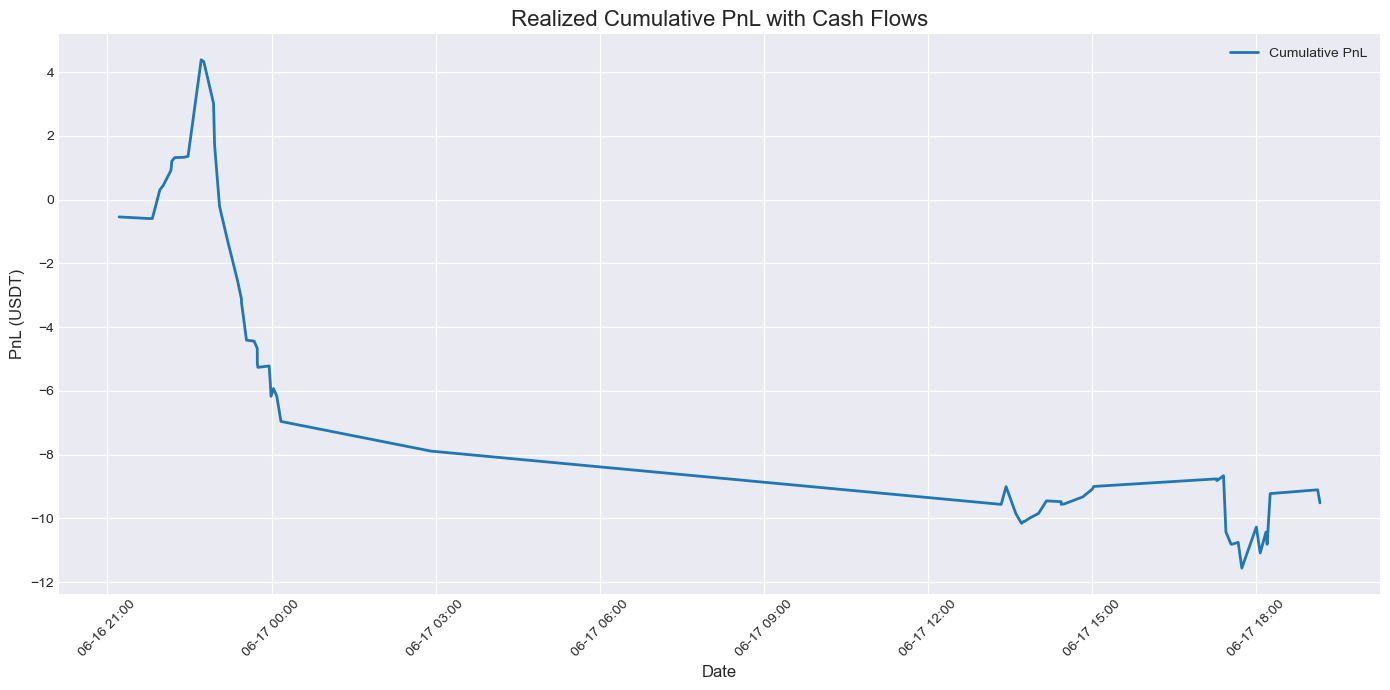

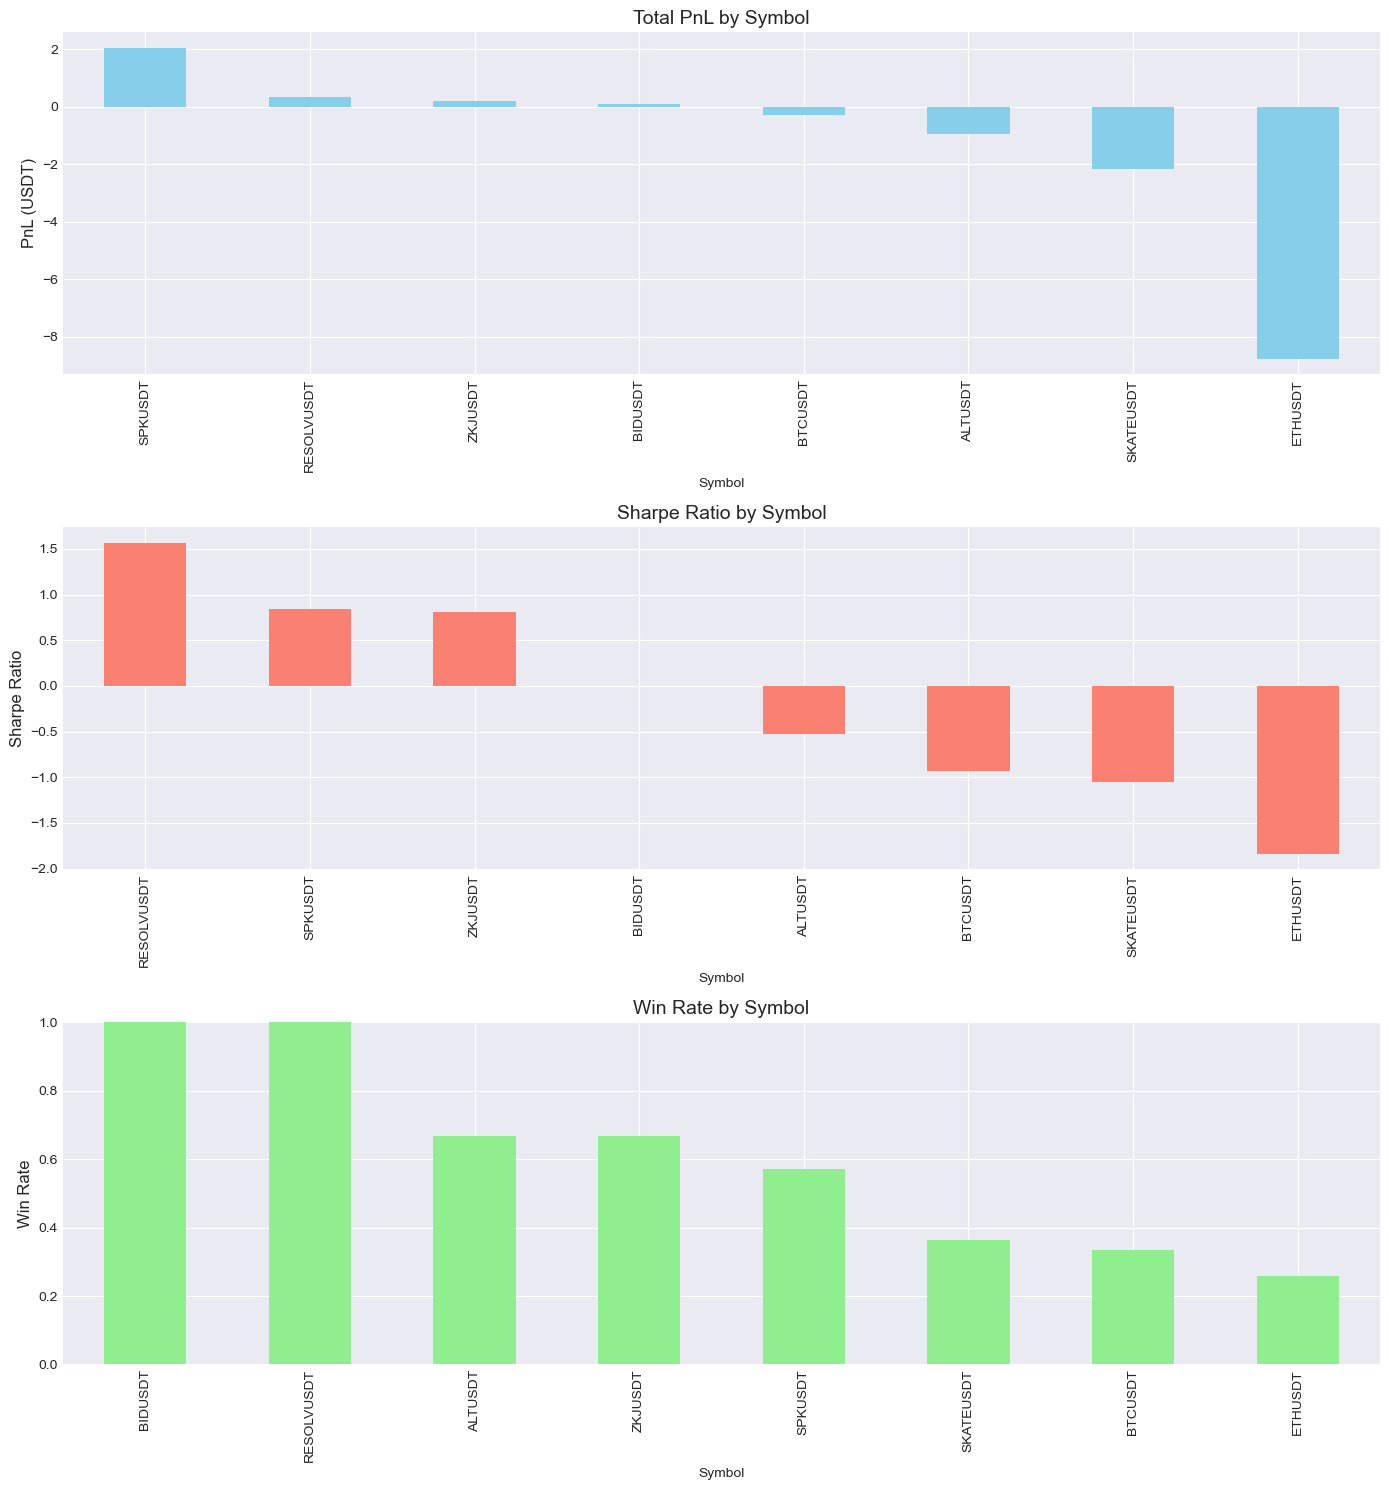

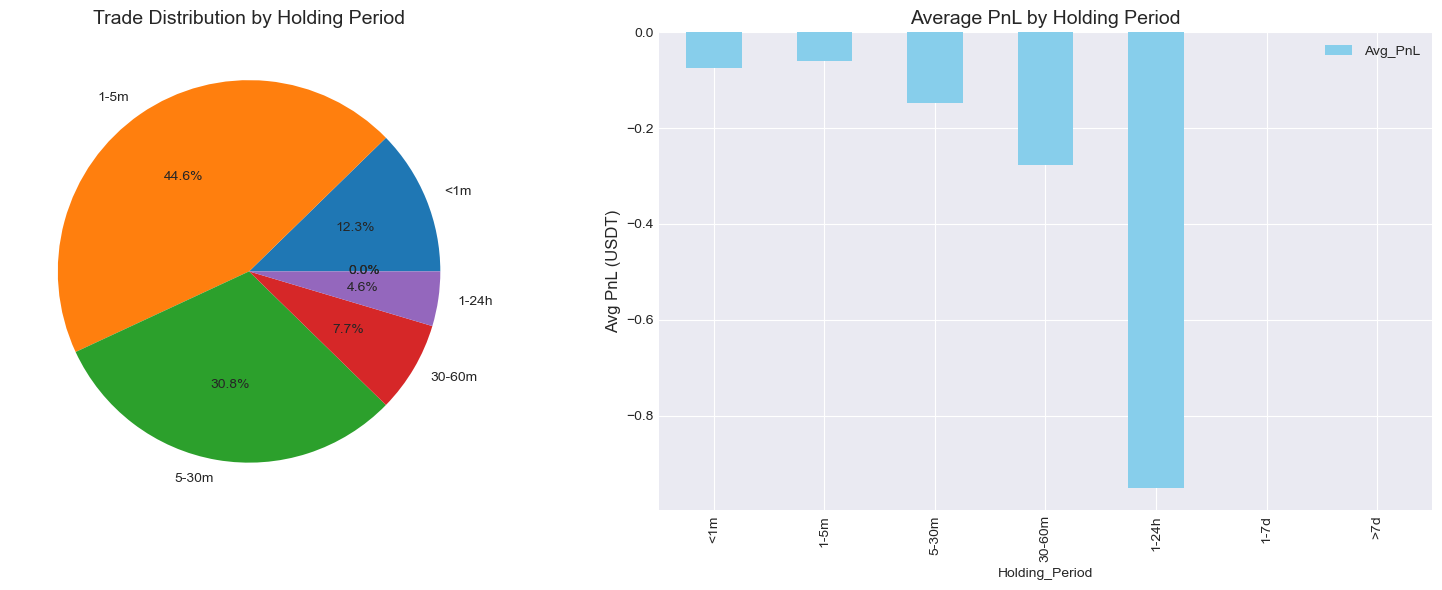


               PROFESSIONAL TRADING PERFORMANCE REPORT                

[OVERVIEW]
Total Trades: 65
Win Rate: 41.54%
Total PnL: -9.512097 USDT
Avg PnL per Trade: -0.146340 USDT
Sharpe Ratio: -1.5680
Max Drawdown: -15.944881 USDT

[BY SYMBOL]
Symbol     Trades   PnL          Win%     Avg Win    Avg Loss   Profit Factor Sharpe    
ALTUSDT    6        -0.965511    66.67%   0.178928   -0.840612  0.2129       -0.5237   
BIDUSDT    1        0.106976     100.00%  0.106976   0.000000   nan          0.0000    
BTCUSDT    3        -0.291829    33.33%   0.063685   -0.177757  0.3583       -0.9320   
ETHUSDT    31       -8.769055    25.81%   0.641327   -0.604334  1.0612       -1.8401   
RESOLVUSDT 3        0.329789     100.00%  0.109930   0.000000   nan          1.5656    
SKATEUSDT  11       -2.177189    36.36%   0.235651   -0.445685  0.5287       -1.0515   
SPKUSDT    7        2.044733     57.14%   0.914239   -0.537407  1.7012       0.8444    
ZKJUSDT    3        0.209989     66.67%   0.132488  

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import timedelta
from collections import defaultdict

# ========== 1. 数据加载与预处理 ==========
def load_and_preprocess_data(file_path):
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    
    # 识别交易方向
    def classify(row):
        if 'long' in row['Type']:
            direction = 'Long'
        elif 'short' in row['Type']:
            direction = 'Short'
        else:
            direction = 'Unknown'
        
        if 'open' in row['Type']:
            action = 'Open'
        elif 'close' in row['Type']:
            action = 'Close'
        else:
            action = 'Unknown'
        return pd.Series([direction, action])
    
    df[['Direction', 'Action']] = df.apply(classify, axis=1)
    
    # 识别资金流动类型
    def classify_cash_flow(row):
        if 'trans_from' in row['Type'] or 'transfer_from' in row['Type']:
            return 'Deposit'
        elif 'trans_to' in row['Type'] or 'transfer_to' in row['Type']:
            return 'Withdrawal'
        elif row['Action'] in ['Open', 'Close']:
            return 'Trade'
        else:
            return 'Other'
    
    df['Cash_Flow_Type'] = df.apply(classify_cash_flow, axis=1)
    
    return df

# ========== 2. 资金流动识别 ==========
def identify_cash_flows(df):
    # 创建资金流动DataFrame
    cash_flows = df[df['Cash_Flow_Type'].isin(['Deposit', 'Withdrawal'])].copy()
    
    if not cash_flows.empty:
        cash_flows['Amount'] = np.where(
            cash_flows['Cash_Flow_Type'] == 'Deposit',
            abs(cash_flows['Amount']),
            -abs(cash_flows['Amount'])
        )
        cash_flows = cash_flows[['Date', 'Amount', 'Cash_Flow_Type', 'Type']]
        cash_flows = cash_flows.rename(columns={'Type': 'Description'})
    
    return cash_flows

# ========== 3. 交易配对与盈亏计算 ==========
def match_trades(df):
    trades = []
    open_trades = defaultdict(list)  # 按币种和方向存储开仓交易
    
    # 只处理交易记录
    trade_df = df[df['Cash_Flow_Type'] == 'Trade'].copy()
    
    for _, row in trade_df.iterrows():
        symbol = row['Futures']
        direction = row['Direction']
        
        if row['Action'] == 'Open':
            # 存储开仓交易
            open_trades[(symbol, direction)].append({
                'Date': row['Date'],
                'Fee': row['Fee'],
                'Amount': abs(row['Amount']) if row['Amount'] != 0 else 0,
                'Type': row['Type']
            })
        elif row['Action'] == 'Close':
            key = (symbol, direction)
            if key in open_trades and open_trades[key]:
                # 获取匹配的开仓交易 (FIFO)
                open_trade = open_trades[key].pop(0)
                
                # 计算盈亏
                # 平仓盈亏 = 平仓金额 + 开仓手续费 + 平仓手续费
                # 注意：开仓手续费为负值（支出），平仓手续费为负值（支出）
                pnl = row['Amount'] + open_trade['Fee'] + row['Fee']
                
                holding_period = (row['Date'] - open_trade['Date']).total_seconds() / 60
                
                trades.append({
                    'Symbol': symbol,
                    'Direction': direction,
                    'Open_Time': open_trade['Date'],
                    'Close_Time': row['Date'],
                    'PnL': pnl,
                    'Holding_Period': holding_period,
                    'Open_Fee': open_trade['Fee'],
                    'Close_Fee': row['Fee'],
                    'Open_Type': open_trade['Type'],
                    'Close_Type': row['Type']
                })
    
    return pd.DataFrame(trades)

# ========== 4. 多币种绩效分析 ==========
def analyze_symbol_performance(df_trades):
    if df_trades.empty:
        return pd.DataFrame()
    
    results = []
    for symbol, group in df_trades.groupby('Symbol'):
        symbol_trades = group.copy()
        symbol_trades = symbol_trades.sort_values('Close_Time')
        symbol_trades['CumPnL'] = symbol_trades['PnL'].cumsum()
        
        total_trades = len(symbol_trades)
        win_trades = symbol_trades[symbol_trades['PnL'] > 0]
        loss_trades = symbol_trades[symbol_trades['PnL'] < 0]
        
        win_rate = len(win_trades) / total_trades if total_trades > 0 else 0
        avg_win = win_trades['PnL'].mean() if not win_trades.empty else 0
        avg_loss = loss_trades['PnL'].mean() if not loss_trades.empty else 0
        profit_factor = abs(avg_win / avg_loss) if avg_loss else np.nan
        
        # 夏普比率 (基于交易盈亏)
        returns = symbol_trades['PnL']
        sharpe = returns.mean() / returns.std() * np.sqrt(len(returns)) if len(returns) > 1 and returns.std() > 0 else 0
        
        # 最大回撤
        cummax = symbol_trades['CumPnL'].cummax()
        drawdown = symbol_trades['CumPnL'] - cummax
        max_drawdown = drawdown.min()
        
        results.append({
            'Symbol': symbol,
            'Total_Trades': total_trades,
            'Total_PnL': symbol_trades['PnL'].sum(),
            'Win_Rate': win_rate,
            'Avg_Win': avg_win,
            'Avg_Loss': avg_loss,
            'Profit_Factor': profit_factor,
            'Sharpe_Ratio': sharpe,
            'Max_Drawdown': max_drawdown,
            'Avg_Holding_Period': symbol_trades['Holding_Period'].mean()
        })
    
    return pd.DataFrame(results)

# ========== 5. 持仓时间分析 ==========
def analyze_holding_periods(df_trades):
    if df_trades.empty:
        return pd.DataFrame()
    
    # 持仓时间分箱
    bins = [0, 1, 5, 30, 60, 1440, 10080, float('inf')]
    labels = ['<1m', '1-5m', '5-30m', '30-60m', '1-24h', '1-7d', '>7d']
    df_trades['Holding_Category'] = pd.cut(
        df_trades['Holding_Period'], 
        bins=bins, 
        labels=labels,
        right=False
    )
    
    results = []
    for category, group in df_trades.groupby('Holding_Category'):
        category_trades = group.copy()
        total_trades = len(category_trades)
        win_rate = (category_trades['PnL'] > 0).mean()
        avg_pnl = category_trades['PnL'].mean()
        total_pnl = category_trades['PnL'].sum()
        
        results.append({
            'Holding_Period': category,
            'Total_Trades': total_trades,
            'Win_Rate': win_rate,
            'Avg_PnL': avg_pnl,
            'Total_PnL': total_pnl,
            'Percentage': total_trades / len(df_trades)
        })
    
    return pd.DataFrame(results)

# ========== 6. 可视化 ==========
def visualize_results(df_trades, symbol_performance, holding_period_perf, cash_flows):
    plt.style.use('seaborn-v0_8-darkgrid')
    
    # 1. 累计盈亏曲线
    if not df_trades.empty:
        df_trades = df_trades.sort_values('Close_Time')
        df_trades['CumPnL'] = df_trades['PnL'].cumsum()
        
        fig, ax = plt.subplots(figsize=(14, 7))
        ax.plot(df_trades['Close_Time'], df_trades['CumPnL'], label='Cumulative PnL', linewidth=2)
        
        # 添加资金流动标记
        if not cash_flows.empty:
            for _, flow in cash_flows.iterrows():
                color = 'green' if flow['Cash_Flow_Type'] == 'Deposit' else 'red'
                marker = '^' if flow['Cash_Flow_Type'] == 'Deposit' else 'v'
                label = 'Deposit' if flow['Cash_Flow_Type'] == 'Deposit' else 'Withdrawal'
                
                # 找到最近的时间点
                closest_idx = df_trades['Close_Time'].searchsorted(flow['Date'])
                if closest_idx < len(df_trades):
                    y_val = df_trades.iloc[closest_idx]['CumPnL']
                else:
                    y_val = df_trades.iloc[-1]['CumPnL'] if not df_trades.empty else 0
                
                ax.scatter(flow['Date'], y_val,
                          color=color, marker=marker, s=100, label=label, alpha=0.7)
        
        ax.set_title('Realized Cumulative PnL with Cash Flows', fontsize=16)
        ax.set_xlabel('Date', fontsize=12)
        ax.set_ylabel('PnL (USDT)', fontsize=12)
        ax.legend()
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    
    # 2. 分币种盈亏
    if not symbol_performance.empty:
        fig, axes = plt.subplots(3, 1, figsize=(14, 15))
        
        # 各币种总盈亏
        symbol_performance.sort_values('Total_PnL', ascending=False).plot.bar(
            x='Symbol', y='Total_PnL', ax=axes[0], legend=False, color='skyblue'
        )
        axes[0].set_title('Total PnL by Symbol', fontsize=14)
        axes[0].set_ylabel('PnL (USDT)', fontsize=12)
        
        # 各币种夏普比率
        symbol_performance.sort_values('Sharpe_Ratio', ascending=False).plot.bar(
            x='Symbol', y='Sharpe_Ratio', ax=axes[1], legend=False, color='salmon'
        )
        axes[1].set_title('Sharpe Ratio by Symbol', fontsize=14)
        axes[1].set_ylabel('Sharpe Ratio', fontsize=12)
        
        # 各币种胜率
        symbol_performance.sort_values('Win_Rate', ascending=False).plot.bar(
            x='Symbol', y='Win_Rate', ax=axes[2], legend=False, color='lightgreen'
        )
        axes[2].set_title('Win Rate by Symbol', fontsize=14)
        axes[2].set_ylabel('Win Rate', fontsize=12)
        axes[2].set_ylim(0, 1)
        
        plt.tight_layout()
        plt.show()
    
    # 3. 持仓时间分析
    if not holding_period_perf.empty and len(holding_period_perf) > 1:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # 持仓时间分布
        holding_period_perf.plot.pie(
            y='Percentage', labels=holding_period_perf['Holding_Period'], 
            autopct='%1.1f%%', ax=axes[0], legend=False
        )
        axes[0].set_title('Trade Distribution by Holding Period', fontsize=14)
        axes[0].set_ylabel('')
        
        # 各持仓时间段的平均盈亏
        holding_period_perf.plot.bar(
            x='Holding_Period', y='Avg_PnL', ax=axes[1], color='skyblue'
        )
        axes[1].set_title('Average PnL by Holding Period', fontsize=14)
        axes[1].set_ylabel('Avg PnL (USDT)', fontsize=12)
        
        plt.tight_layout()
        plt.show()

# ========== 7. 生成交易报告 ==========
def generate_trading_report(df_trades, symbol_performance, holding_period_perf, cash_flows):
    report = {
        'overview': {},
        'by_symbol': {},
        'cash_flows': {},
        'holding_period': {}
    }
    
    # 1. 总体概况
    if not df_trades.empty:
        total_trades = len(df_trades)
        win_rate = (df_trades['PnL'] > 0).mean()
        total_pnl = df_trades['PnL'].sum()
        avg_pnl = df_trades['PnL'].mean()
        sharpe = df_trades['PnL'].mean() / df_trades['PnL'].std() * np.sqrt(total_trades) if total_trades > 1 and df_trades['PnL'].std() > 0 else 0
        
        # 计算最大回撤
        cummax = df_trades['PnL'].cumsum().cummax()
        drawdown = df_trades['PnL'].cumsum() - cummax
        max_drawdown = drawdown.min()
        
        report['overview'] = {
            'total_trades': total_trades,
            'win_rate': win_rate,
            'total_pnl': total_pnl,
            'avg_pnl': avg_pnl,
            'sharpe_ratio': sharpe,
            'max_drawdown': max_drawdown
        }
    
    # 2. 分币种表现
    if not symbol_performance.empty:
        for _, row in symbol_performance.iterrows():
            report['by_symbol'][row['Symbol']] = {
                'total_trades': row['Total_Trades'],
                'total_pnl': row['Total_PnL'],
                'win_rate': row['Win_Rate'],
                'avg_win': row['Avg_Win'],
                'avg_loss': row['Avg_Loss'],
                'profit_factor': row['Profit_Factor'],
                'sharpe_ratio': row['Sharpe_Ratio'],
                'max_drawdown': row['Max_Drawdown'],
                'avg_holding_period': row['Avg_Holding_Period']
            }
    
    # 3. 资金流动
    if not cash_flows.empty:
        deposits = cash_flows[cash_flows['Cash_Flow_Type'] == 'Deposit']['Amount'].sum()
        withdrawals = cash_flows[cash_flows['Cash_Flow_Type'] == 'Withdrawal']['Amount'].abs().sum()
        net_cash_flow = deposits - withdrawals
        
        report['cash_flows'] = {
            'total_deposits': deposits,
            'total_withdrawals': withdrawals,
            'net_cash_flow': net_cash_flow,
            'transactions': cash_flows.to_dict('records')
        }
    
    # 4. 持仓时间分析
    if not holding_period_perf.empty:
        for _, row in holding_period_perf.iterrows():
            report['holding_period'][row['Holding_Period']] = {
                'total_trades': row['Total_Trades'],
                'win_rate': row['Win_Rate'],
                'avg_pnl': row['Avg_PnL'],
                'total_pnl': row['Total_PnL'],
                'percentage': row['Percentage']
            }
    
    return report

# ========== 主函数 ==========
def main(file_path):
    # 1. 加载和预处理数据
    df = load_and_preprocess_data(file_path)
    
    # 2. 识别资金流动
    cash_flows = identify_cash_flows(df)
    
    # 3. 配对交易并计算盈亏
    df_trades = match_trades(df)
    
    # 4. 多币种绩效分析
    symbol_performance = analyze_symbol_performance(df_trades)
    
    # 5. 持仓时间分析
    holding_period_perf = analyze_holding_periods(df_trades)
    
    # 6. 可视化结果
    visualize_results(df_trades, symbol_performance, holding_period_perf, cash_flows)
    
    # 7. 生成交易报告
    report = generate_trading_report(df_trades, symbol_performance, holding_period_perf, cash_flows)
    
    # 打印报告摘要
    print("\n" + "="*70)
    print("PROFESSIONAL TRADING PERFORMANCE REPORT".center(70))
    print("="*70)
    
    if report['overview']:
        ov = report['overview']
        print("\n[OVERVIEW]")
        print(f"Total Trades: {ov['total_trades']}")
        print(f"Win Rate: {ov['win_rate']:.2%}")
        print(f"Total PnL: {ov['total_pnl']:.6f} USDT")
        print(f"Avg PnL per Trade: {ov['avg_pnl']:.6f} USDT")
        print(f"Sharpe Ratio: {ov['sharpe_ratio']:.4f}")
        print(f"Max Drawdown: {ov['max_drawdown']:.6f} USDT")
    
    if report['by_symbol']:
        print("\n[BY SYMBOL]")
        print("{:<10} {:<8} {:<12} {:<8} {:<10} {:<10} {:<12} {:<10}".format(
            'Symbol', 'Trades', 'PnL', 'Win%', 'Avg Win', 'Avg Loss', 'Profit Factor', 'Sharpe'
        ))
        for symbol, perf in report['by_symbol'].items():
            print("{:<10} {:<8} {:<12.6f} {:<8.2%} {:<10.6f} {:<10.6f} {:<12.4f} {:<10.4f}".format(
                symbol, 
                perf['total_trades'], 
                perf['total_pnl'], 
                perf['win_rate'], 
                perf['avg_win'], 
                perf['avg_loss'], 
                perf['profit_factor'], 
                perf['sharpe_ratio']
            ))
    
    if report['cash_flows']:
        cf = report['cash_flows']
        print("\n[CASH FLOWS]")
        print(f"Total Deposits: {cf['total_deposits']:.6f} USDT")
        print(f"Total Withdrawals: {cf['total_withdrawals']:.6f} USDT")
        print(f"Net Cash Flow: {cf['net_cash_flow']:.6f} USDT")
        
        # 打印资金流动明细
        if 'transactions' in cf and cf['transactions']:
            print("\nCash Flow Details:")
            print("{:<25} {:<15} {:<12} {:<30}".format(
                'Date', 'Type', 'Amount', 'Description'
            ))
            for flow in cf['transactions']:
                print("{:<25} {:<15} {:<12.6f} {:<30}".format(
                    str(flow['Date']), 
                    flow['Cash_Flow_Type'], 
                    flow['Amount'], 
                    flow.get('Description', '')
                ))
    
    if report['holding_period']:
        print("\n[HOLDING PERIOD ANALYSIS]")
        print("{:<10} {:<8} {:<8} {:<12} {:<12} {:<10}".format(
            'Period', 'Trades', 'Win%', 'Avg PnL', 'Total PnL', 'Percentage'
        ))
        for period, stats in report['holding_period'].items():
            print("{:<10} {:<8} {:<8.2%} {:<12.6f} {:<12.6f} {:<10.2%}".format(
                period, 
                stats['total_trades'], 
                stats['win_rate'], 
                stats['avg_pnl'], 
                stats['total_pnl'], 
                stats['percentage']
            ))
    
    print("\n" + "="*70)
    print("END OF REPORT".center(70))
    print("="*70)
    
    return report

# ========== 执行分析 ==========
if __name__ == "__main__":
    # 替换为实际文件路径
    file_path = '20250617191200.csv'
    report = main(file_path)